<a href="https://colab.research.google.com/github/fauziah-azzhr/PertemuanKesembilan/blob/main/TugasSegmentasiCitra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload 3 gambar:
1. Citra Bimodal
2. Citra Iluminasi Tidak Merata
3. Citra Overlapping


Saving 9.1.jpg to 9.1.jpg
Saving 9.2.jpg to 9.2.jpg
Saving 9.3.jpg to 9.3.jpg


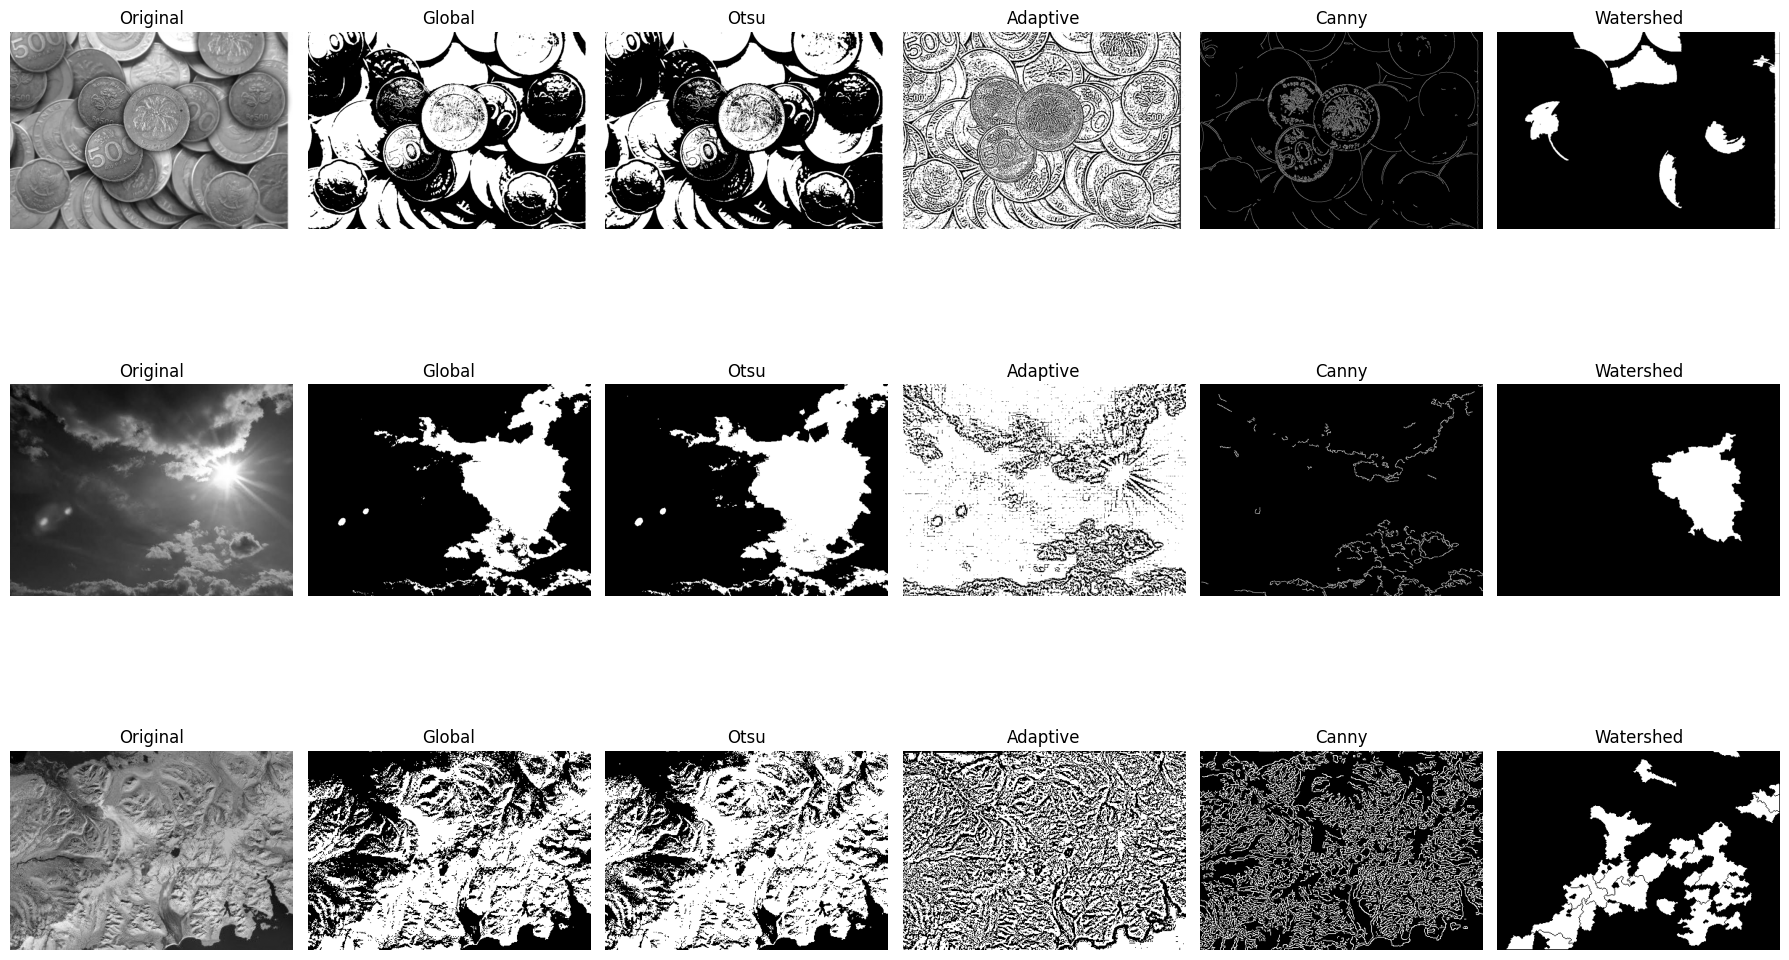

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

print("Upload 3 gambar:")
print("1. Citra Bimodal")
print("2. Citra Iluminasi Tidak Merata")
print("3. Citra Overlapping")

uploaded = files.upload()
file_names = list(uploaded.keys())

if len(file_names) != 3:
    raise Exception("Harus upload tepat 3 gambar!")

def load_gray(path):
    img = cv2.imread(path)
    if img is None:
        raise Exception(f"Gagal baca {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def segment(img):
    hasil = {}

    # Global Threshold
    _, hasil["Global"] = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

    # Otsu
    _, hasil["Otsu"] = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    # Adaptive
    hasil["Adaptive"] = cv2.adaptiveThreshold(
        img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,11,2
    )

    # Canny
    hasil["Canny"] = cv2.Canny(img,100,200)

    # Watershed
    color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    _, thresh = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    kernel = np.ones((3,3),np.uint8)
    opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel,2)

    bg = cv2.dilate(opening,kernel,3)
    dist = cv2.distanceTransform(opening,cv2.DIST_L2,5)
    _, fg = cv2.threshold(dist,0.5*dist.max(),255,0)

    fg = np.uint8(fg)
    unknown = cv2.subtract(bg,fg)

    _, markers = cv2.connectedComponents(fg)
    markers += 1
    markers[unknown==255] = 0

    markers = cv2.watershed(color,markers)

    ws = np.zeros_like(img)
    ws[markers > 1] = 255

    hasil["Watershed"] = ws

    return hasil

data = []

for f in file_names:
    img = load_gray(f)
    hasil = segment(img)
    data.append((f, img, hasil))

plt.figure(figsize=(18,12))

for i, (name, img, hasil) in enumerate(data):

    row = i * 6

    # Original
    plt.subplot(3,6,row+1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    j = 2
    for metode, res in hasil.items():
        plt.subplot(3,6,row+j)
        plt.imshow(res, cmap='gray')
        plt.title(metode)
        plt.axis('off')
        j += 1

plt.tight_layout()
plt.show()